In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch


In [2]:
# 1. Load the fully preprocessed data (before feature selection)
df = pd.read_csv('../data/cleaned_heart_disease.csv')
X = df.drop('target', axis=1)
y_true = df['target'] # Keep true labels for comparison

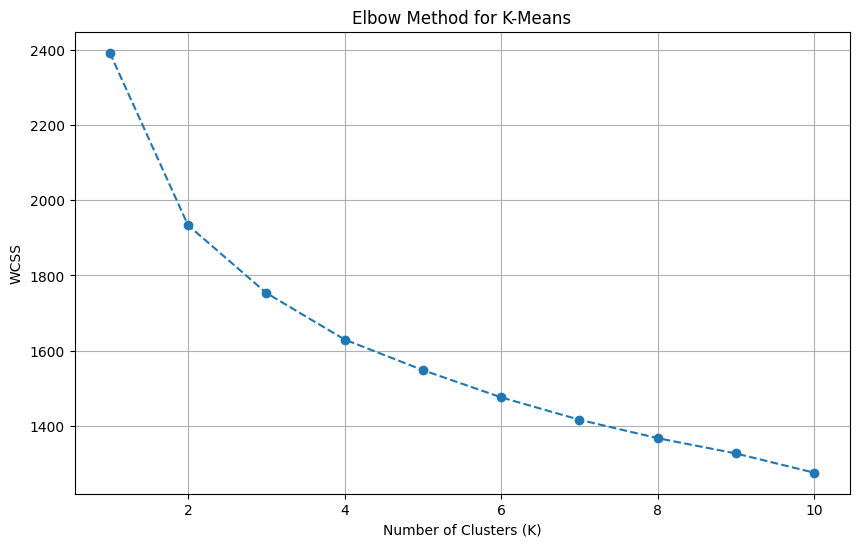

In [3]:
# 2. K-Means Clustering
# Use the Elbow Method to find the optimal number of clusters
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# The elbow appears at K=2, which makes sense for our binary problem.
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

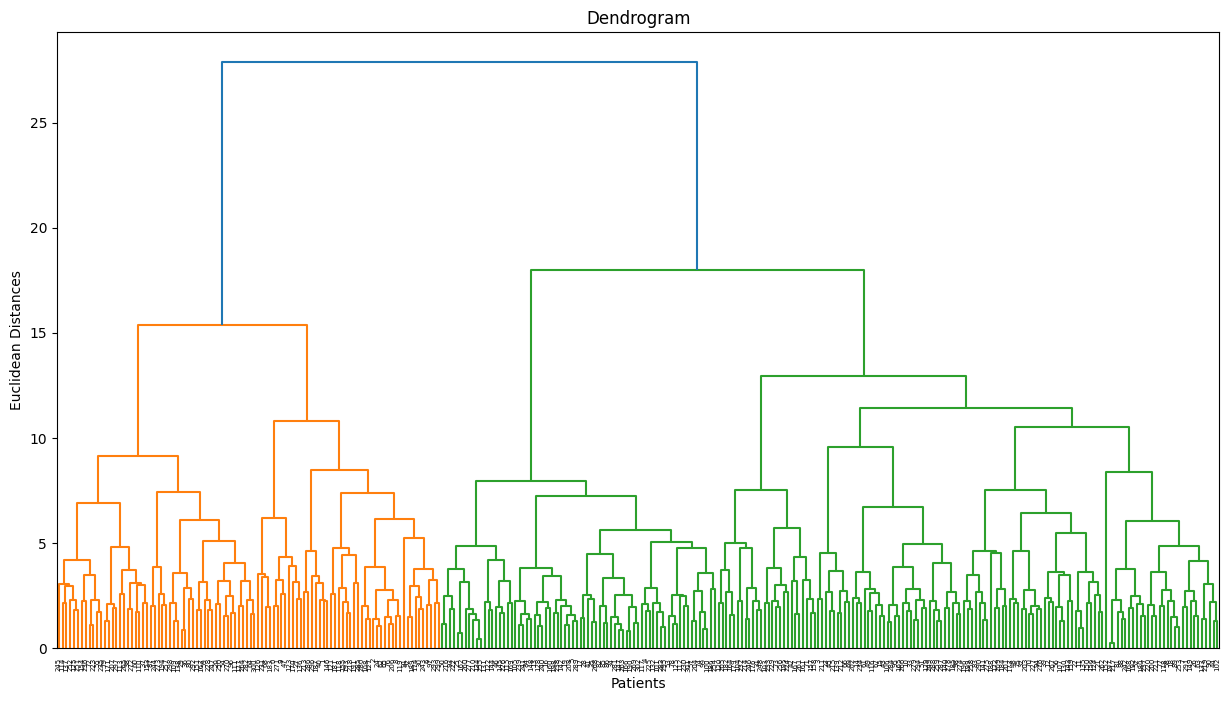

In [4]:
# 3. Hierarchical Clustering
# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Patients')
plt.ylabel('Euclidean Distances')
plt.show()

# From the dendrogram, 2 clusters seem appropriate.
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

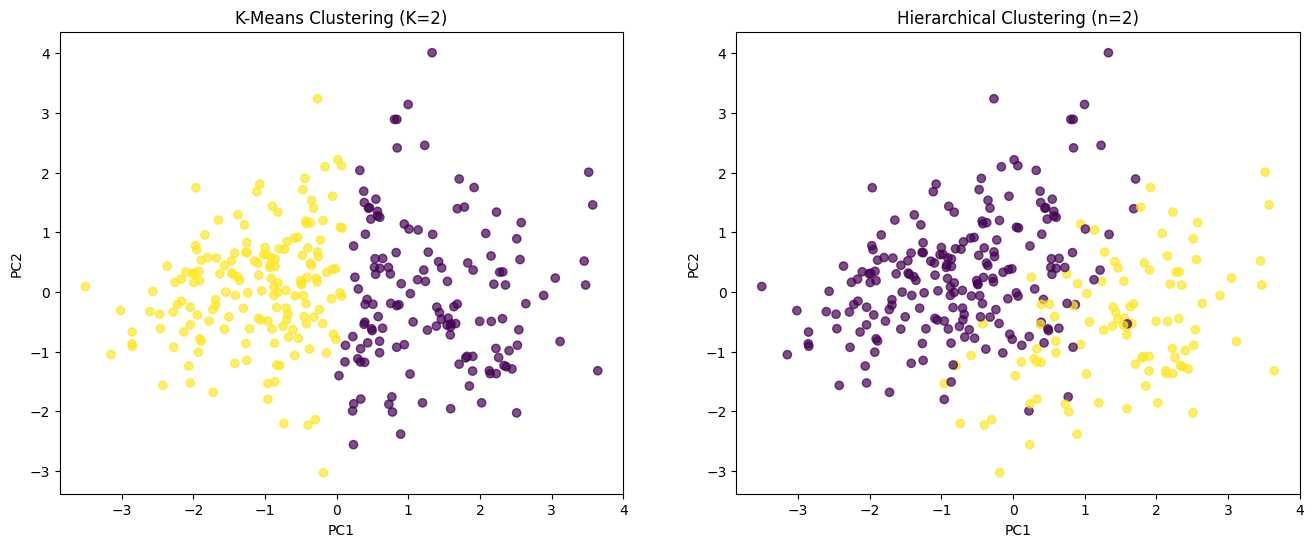

K-Means Clustering vs. Actual Labels:
Predicted Cluster    0    1
Actual                     
0                   37  127
1                  101   38

Hierarchical Clustering vs. Actual Labels:
Predicted Cluster    0   1
Actual                    
0                  144  20
1                   59  80


In [5]:
# 4. Compare clusters with actual labels
# Use PCA to visualize the clusters in 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Visualization
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', alpha=0.7)
ax1.set_title('K-Means Clustering (K=2)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# Hierarchical Clustering Visualization
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hc, cmap='viridis', alpha=0.7)
ax2.set_title('Hierarchical Clustering (n=2)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.show()

# Quantitative comparison
kmeans_crosstab = pd.crosstab(y_true, y_kmeans, rownames=['Actual'], colnames=['Predicted Cluster'])
hc_crosstab = pd.crosstab(y_true, y_hc, rownames=['Actual'], colnames=['Predicted Cluster'])

print("K-Means Clustering vs. Actual Labels:")
print(kmeans_crosstab)
print("\nHierarchical Clustering vs. Actual Labels:")
print(hc_crosstab)